In [1]:
#Imports
import os #File Paths
import re #Extractions
from tqdm.autonotebook import tqdm #Progress Bars
from math import floor, log10 #Scaling and logic
import random #Choose GRBs


#Math
import matplotlib.pyplot as plt #Plotting
import numpy as np #Math, arrays, etc.


#Data
import pandas as pd #Data as DF
df=pd.read_csv('GRB_Minimum_Time_Scales.csv')


#Interaction w/ Fermi Data
from gdt.missions.fermi.gbm.tte import GbmTte #Open and slicing
from gdt.core.binning.unbinned import bin_by_time #Binning


#URL Handler
from urllib.request import urlopen, urlretrieve #Scrape detectors


#Image Processing
from PIL import Image, ImageSequence #GIF Frames
import cv2 #Image masking


#Project Directory
os.makedirs("MVTcode", exist_ok=True)


#Clean Data Frame
df.drop(columns=['GRBName','z','tS_N','tS_N_err','tStart','tStop','Xtmin','tmin_upp_lim','XtS_N'], inplace=True)
df=df.rename(columns={'tmin_err': 'MVT_err','tmin': 'MVT'})
df = df[df["MVT"] < 1]
df = df.iloc[:, [0, 1, 3, 2, 4]]
df["TriggerID"] = df["TriggerID"].astype(str)
df["TriggerID"] = df["TriggerID"].str.zfill(9)
df.reset_index(drop = True, inplace = True)

/var/folders/7m/2rx5r0hs31b2t2_md4xkjt900000gn/T/ipykernel_62993/1888899474.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm #Progress Bars


In [2]:
def getInfo(grb_name):   #Scrape known GRB info
  grb_ID = grb_name.removeprefix("GRB")

  grb_row = df.loc[df["TriggerID"] == grb_ID]

  if grb_row.empty:
      raise ValueError(f"TriggerID {grb_name} not found")

  grb_row = grb_row.iloc[0]

  known_MVT = grb_row["MVT"]
  known_MVT_err = grb_row["MVT_err"]
  known_T90 = grb_row["T90"]
  known_T90_err = grb_row["T90_err"]

  return known_MVT, known_MVT_err, known_T90, known_T90_err


def cropMargins(img):   #Isolate only detector images, eliminate margins
    left_crop   = 72
    right_crop  = 39
    top_crop    = 34
    bottom_crop = 41

    width, height = img.size
    return img.crop((left_crop, top_crop, width-right_crop, height-bottom_crop))


def splitDetectors(img, crop_dimensions, detector_names):   #Split image into 12 single detector images
    img = cropMargins(img)
    cropped_width, cropped_height = img.size

    detector_images = {}
    detector_index = 0

    for row, (frac_start, frac_end) in enumerate(crop_dimensions):   #Loop through 6 rows
        top_pixel = int(frac_start * cropped_height)   #Fraction to pixels
        bottom_pixel = int(frac_end * cropped_height)

        for column in range(2):   #Loop through 2 columns
            image_left = column * (cropped_width // 2)   #Calculate boundaries
            image_right = (column + 1) * (cropped_width // 2)

            #Crop detector
            detector_images[detector_names[detector_index]] = img.crop((image_left, top_pixel, image_right, bottom_pixel))
            detector_index += 1

    return detector_images


def chooseDetector(grb_name):   #Determine which detectors to use

  url = "https://heasarc.gsfc.nasa.gov/FTP/fermi/data/gbm/triggers/20{:}/bn{:}/quicklook/glg_lc_all_bn{:}.gif".format(grb_name[3:5], grb_name.lstrip('GRB'), grb_name.lstrip('GRB'))
  gif_filename = "glg_lc_all_bn{:}.gif".format(grb_name.lstrip('GRB'))
  gif_filepath = os.path.join("MVTcode", grb_name, gif_filename)


  if os.path.exists(gif_filepath):
    print(f"{grb_name} already downloaded")
  else:
    urlretrieve(url, gif_filepath)

  #Open gif and select first frame in RGB
  gif = Image.open(gif_filepath)
  img = next(ImageSequence.Iterator(gif)).convert("RGB")

  #Horizontal crop boundaries
  crop_dimensions = [
      (0.00, 0.165),
      (0.167, 0.33),
      (0.335, 0.498),
      (0.501, 0.66),
      (0.668, 0.825),
      (0.835, 1.00),
  ]


  detector_names = [
      "glg_lc_bn{:}_0".format(grb_name.lstrip('GRB')), "glg_lc_bn{:}_1".format(grb_name.lstrip('GRB')),
      "glg_lc_bn{:}_2".format(grb_name.lstrip('GRB')), "glg_lc_bn{:}_3".format(grb_name.lstrip('GRB')),
      "glg_lc_bn{:}_4".format(grb_name.lstrip('GRB')), "glg_lc_bn{:}_5".format(grb_name.lstrip('GRB')),
      "glg_lc_bn{:}_6".format(grb_name.lstrip('GRB')), "glg_lc_bn{:}_7".format(grb_name.lstrip('GRB')),
      "glg_lc_bn{:}_8".format(grb_name.lstrip('GRB')), "glg_lc_bn{:}_9".format(grb_name.lstrip('GRB')),
      "glg_lc_bn{:}_a".format(grb_name.lstrip('GRB')), "glg_lc_bn{:}_b".format(grb_name.lstrip('GRB')),
  ]

  #Split image into 12 single detector images
  detector_images = splitDetectors(img, crop_dimensions, detector_names)


  for name, roi in detector_images.items():
      roi.save(os.path.join("MVTcode/{:}/detector_images/cropped".format(grb_name), f"{name}c.png"))

  #Mask images to only LC
  for name in detector_images.keys():

    detector_img = cv2.imread(os.path.join("MVTcode/{:}/detector_images/cropped".format(grb_name), f"{name}c.png"))

    hsv_img = cv2.cvtColor(detector_img, cv2.COLOR_BGR2HSV)   #Convert to HSV color space

    #Color range, blue of light curve
    hsv_lower = np.array([60, 50, 75])
    hsv_upper = np.array([128, 255, 255])

    #Create, apply, save
    mask = cv2.inRange(hsv_img, hsv_lower, hsv_upper)

    masked_img = cv2.bitwise_and(detector_img, detector_img, mask=mask)

    cv2.imwrite(os.path.join("MVTcode/{:}/detector_images/masked".format(grb_name), f"{name}m.png"), masked_img)


  detector_maxes = {

    }

  #Measure peak height of each detectors LC
  for name in detector_images.keys():
    im = cv2.imread(os.path.join("MVTcode/{:}/detector_images/masked".format(grb_name), f"{name}m.png"))

    grayscale_img = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)   #Apply grayscale

    resolution_scale = 4   #Scale up 400% so its smoother

    upscaled = cv2.resize(grayscale_img, None, fx=resolution_scale, fy=resolution_scale, interpolation=cv2.INTER_CUBIC)

    upscaled_height, upscaled_width = upscaled.shape

    column_position = []
    vertical_center = []

    for x in range(upscaled_width):
        vertical_slice = upscaled[:, x]

        if vertical_slice.sum() > 0:   #If the line exists in this column
            y_indices = np.arange(upscaled_height)
            y_center = np.sum(y_indices * vertical_slice) / np.sum(vertical_slice)

            column_position.append(x)
            vertical_center.append(y_center)

    vertical_center = upscaled_height - np.array(vertical_center)

    detector_maxes[name] = vertical_center.max()

  #Sort detectors, choose top 5
  sorted_maxes = dict(sorted(detector_maxes.items(), key=lambda item: item[1]))
  all_detector_names = list(sorted_maxes.keys())
  list_of_detectors = all_detector_names[-5:]
  return list_of_detectors


def getDetectors(grb_name, list_of_detectors):   #Download detector data
  list_of_detectors = [re.findall(r'_([0-9a-b])$', d)[0] for d in list_of_detectors]

  #Download Detector Info
  url = 'https://heasarc.gsfc.nasa.gov/FTP/fermi/data/gbm/triggers/20{:}/bn{:}/current/'.format(grb_name[3:5], grb_name.lstrip('GRB'))

  #Archive connection issue fail safe
  try:
      archive_files = np.unique(re.findall(r'glg_tte_n[0-9a-b]_bn[0-9]{9}_v[0-9]{2}\.fit',urlopen(url).read().decode('ascii')))
  except:
      archive_files = []


  list_of_files = []
  detector_folder = os.path.join("MVTcode/{:}/detectors".format(grb_name))

  #If detector files doesn't already exist download it
  for filename in archive_files:
    detector_path = os.path.join(detector_folder, filename)
    if filename in os.listdir(detector_folder):
      print("{:} already downloaded".format(filename))
      list_of_files.append(filename)
    elif re.findall(r'n([0-9]|[a-b])', filename)[0] in list_of_detectors:
      urlretrieve(url + filename, detector_path)
      list_of_files.append(filename)
    else:
      pass

  return list_of_files


def bins(known_MVT):   #Determine bin logspace
  order_magnitude = -floor(log10(abs(known_MVT)))   #Find order of magnitude of MVT

  #Choose one OM above and below for logspace
  bin_upper = -order_magnitude+1
  bin_lower = -order_magnitude-1

  bin_sizes = np.logspace(bin_lower,bin_upper,100)
  return bin_sizes


def getTimes(bin_sizes, list_of_files, grb_name):   #Determine common time interval between detectors
  list_of_start_times = []
  list_of_end_times = []
  ref_bin = bin_sizes[0]

  #Check the start/stop times for each lightcurve
  for filename in list_of_files:
    #Open file and convert to the correct format
    tte = GbmTte.open(os.path.join("MVTcode", grb_name, "detectors", filename))
    phaii = tte.to_phaii(bin_by_time, ref_bin, time_ref=0.0)

    list_of_start_times.append(phaii.time_range[0])
    list_of_end_times.append(phaii.time_range[1])

  #Ensure these lists are not empty before calling max/min
  if not list_of_start_times or not list_of_end_times:
      raise ValueError("Could not determine start/end times from processed files. Check file integrity.")

  #Get latest start time and earliest end time
  start_time = np.ceil(max(list_of_start_times))
  end_time = np.floor(min(list_of_end_times))

  return start_time, end_time


def findVariance(bin_sizes, start_time, end_time, detector_full_path, known_T90, grb_name):   #Determine variability per bin
  detector_full_path = [os.path.join("MVTcode", grb_name, "detectors", f) for f in detector_full_path]
  variability_per_bin = []
  valid_bins = []
  center_time_bins = []
  photon_counts_sum = None
  for current_bin in tqdm(bin_sizes):   #For each bin

    #Trim to common time interval, rebin; Done for first bin of first detector to establish and save time
    tte = GbmTte.open(detector_full_path[0])
    tte = tte.slice_time([start_time, end_time])
    phaii = tte.to_phaii(bin_by_time, current_bin, time_ref=0.0)

    photon_counts_sum = None
    center_time_bins = None

    for filename in detector_full_path:
      tte = GbmTte.open(filename)
      tte = tte.slice_time([start_time, end_time])
      phaii = tte.to_phaii(bin_by_time, current_bin, time_ref=0.0)

      lc = phaii.to_lightcurve()
      time_bins = lc.centroids   #Time at center of each bin
      counts_per_bin = lc.counts   #Photon counts per bin

      if photon_counts_sum is None:
          photon_counts_sum = counts_per_bin.copy()
          center_time_bins = time_bins.copy()
      else:
          least_bins = min(len(photon_counts_sum), len(counts_per_bin))   #Align lengths
          #Trim both
          photon_counts_sum = photon_counts_sum[:least_bins]
          counts_per_bin = counts_per_bin[:least_bins]
          center_time_bins = center_time_bins[:least_bins]
          #Summed LC across detectors
          photon_counts_sum += counts_per_bin


    #If nothing contributed, skip this bin size
    if photon_counts_sum is None or np.all(photon_counts_sum == 0):
        variability_per_bin.append(np.nan)
        continue

    #Differentiate LC, measure variability
    differential_LC = np.diff(photon_counts_sum)

    #Realign array lengths after differentiating
    aligned_time_bins = (center_time_bins[:-1] + center_time_bins[1:]) / 2

    #Split the lightcurve into burst and background (before and after peak)
    time_during = differential_LC[(aligned_time_bins >= 0) & (aligned_time_bins < known_T90)]
    time_before = differential_LC[(aligned_time_bins >= -known_T90) & (aligned_time_bins < 0)]

    if len(time_during) <= 1 or len(time_before) <= 1:   #Skip anything with not enough points
        continue

    bkg_variance = np.var(time_before)
    if bkg_variance == 0:   #Avoid divide by 0 issues
        continue

    #Calculate the variance of burst vs bkg
    variance_ratio = (np.var(time_during))/(np.var(time_before))

    #Adjust to bin width size to compare across scales
    variability_over_bin = variance_ratio/current_bin

    variability_per_bin.append(variability_over_bin)
    valid_bins.append(current_bin)

  return variability_per_bin, valid_bins, center_time_bins, photon_counts_sum


def plotLightcurve(center_time_bins, photon_counts_sum):   #Create Lightcurve
    plt.plot(center_time_bins, photon_counts_sum)
    plt.xlabel("Time (s)")
    plt.ylabel("Photon Counts")
    plt.title(f"Lightcurve")
    plt.show()


def computeMVT(fit_lower, fit_upper, bin_sizes, variability_per_bin, known_MVT, min_points=6):   #Compute MVT
  #If range is too small skip
  if fit_upper - fit_lower < min_points:
      return np.inf, None, None

  #Convert from linear to logspace
  bins_log = np.log10(bin_sizes[fit_lower:fit_upper])
  var_bin_log = np.log10(variability_per_bin[fit_lower:fit_upper])

  #Quadratic fit in log-log
  quad_fit_log = np.polyfit(bins_log, var_bin_log, deg=2)

  #Enforce upward-opening parabola
  if quad_fit_log[0] <= 0:
      return np.inf, None, None

  #Derivative and minimum of fit
  fit_derivative = np.polyder(quad_fit_log)
  fit_min_log = np.roots(fit_derivative)

  #Reject complex or multiple roots
  if len(fit_min_log) != 1 or not np.isreal(fit_min_log[0]):
      return np.inf, None, None

  #Convert from logspace to linear
  fit_min_log = np.real(fit_min_log[0])
  fit_min = 10**fit_min_log

  #Minimum must lie inside the fit window
  if not (bin_sizes[fit_lower] <= fit_min <= bin_sizes[fit_upper-1]):
      return np.inf, None, None

  #Find percent error
  error = (abs(fit_min - known_MVT) / known_MVT) * 100

  return error, fit_min, quad_fit_log


def boxSmooth(data, box_size):   #Smooth Data
  smooth = []
  half_box = box_size // 2   #Half box size to center

  for i in range(len(data)):
    start = max(0, i - half_box)   #Dont go below 0 index
    end = min(len(data), i + half_box + 1)   #Dont go above max index
    value = data[start:end]   #Slice window around current point
    smooth.append(np.mean(value))   #Replace point with window average

  return np.array(smooth)


def oldRange(valid_bins, variability_per_bin, known_MVT):   #Find best range to fit
  best_error = np.inf
  best_range = None
  best_min = None
  best_fit = None

  valid_bins_length = len(valid_bins)

  #Try all possible fitting ranges (Must be at least 10 points)
  for fit_lower in range(0, valid_bins_length - 10):
    for fit_upper in range(fit_lower + 10, valid_bins_length):
        #Compute the MVT
        error, fit_min, quad_fit_log = computeMVT(fit_lower, fit_upper, valid_bins, variability_per_bin, known_MVT)
        #If its the less than the best error, become new error
        if error < best_error:
            best_error = error
            best_range = (fit_lower, fit_upper)
            best_min = fit_min
            best_fit = quad_fit_log

  #Extract best range
  fit_lower, fit_upper = best_range
  return fit_lower, fit_upper


def findRange(valid_bins, variability_per_bin, known_MVT):   #Find best range to fit
  smooth = boxSmooth(np.log10(variability_per_bin), 5)   #Smooth variance in logspace
  smooth_diff = np.diff(smooth)   #Derivative of smoothed curve
  turning_point = np.argmin(np.abs(smooth_diff))   #Index where slope is closest to 0
  variability_smoothed = 10**smooth   #Convert back to linear space

  half_width_smooth = 10
  fit_lower_smooth, fit_upper_smooth = None, None

  #Expand window around turning point until valid smoothed fit is found
  while half_width_smooth <= len(valid_bins) // 2:
    fl = max(0, turning_point - half_width_smooth)
    fu = min(len(valid_bins), turning_point + half_width_smooth + 1)
    error_smoothed, fit_min_smooth, quad_fit_log_smoothed = computeMVT(fl, fu, valid_bins, variability_smoothed, known_MVT)
    if quad_fit_log_smoothed is not None:
        fit_lower_smooth, fit_upper_smooth = fl, fu
        break
    half_width_smooth += 5

  #Expand window around turning point until valid raw fit is found
  half_width_turn = 10
  fit_lower_turn, fit_upper_turn = None, None

  while half_width_turn <= len(valid_bins) // 2:
      fl = max(0, turning_point - half_width_turn)
      fu = min(len(valid_bins), turning_point + half_width_turn + 1)
      error_turn, fit_min_turn, quad_fit_log_turn = computeMVT(fl, fu, valid_bins, variability_per_bin, known_MVT)
      if quad_fit_log_turn is not None:
          fit_lower_turn, fit_upper_turn = fl, fu
          break
      half_width_turn += 5

  #Get original brute force best fit for comparison
  old_fit_lower, old_fit_upper = oldRange(valid_bins, variability_per_bin, known_MVT)
  error_original, fit_min_original, quad_fit_log_original = computeMVT(old_fit_lower, old_fit_upper, valid_bins, variability_per_bin, known_MVT)

  #Rebuild fit curves over each range in logspace, None if no fit found
  bins_log_original = np.log10(valid_bins[old_fit_lower:old_fit_upper])
  bins_log_smooth = np.log10(valid_bins[fit_lower_smooth:fit_upper_smooth]) if fit_lower_smooth is not None else None
  bins_log_turn = np.log10(valid_bins[fit_lower_turn:fit_upper_turn]) if fit_lower_turn is not None else None

  #Convert fits back to linear space, None if no fit found
  fit_var_bin_original = 10 ** np.polyval(quad_fit_log_original, bins_log_original) if quad_fit_log_original is not None else None
  fit_var_bin_smoothed = 10 ** np.polyval(quad_fit_log_smoothed, bins_log_smooth) if bins_log_smooth is not None else None
  fit_var_bin_turn = 10 ** np.polyval(quad_fit_log_turn, bins_log_turn) if bins_log_turn is not None else None

  return (half_width_smooth, half_width_turn, fit_lower_smooth, fit_upper_smooth, fit_lower_turn, fit_upper_turn, old_fit_lower, old_fit_upper, fit_min_original, fit_min_smooth, fit_min_turn,
         error_original, error_smoothed, error_turn, fit_var_bin_original, fit_var_bin_smoothed, fit_var_bin_turn, variability_smoothed)


def prints(grb_name, known_T90, known_T90_err, known_MVT, known_MVT_err, list_of_detectors, old_fit_lower, old_fit_upper,
         fit_lower_smooth, fit_upper_smooth, fit_lower_turn, fit_upper_turn, fit_min_original, fit_min_smooth, fit_min_turn,
         half_width_smooth, half_width_turn, error_original, error_smoothed, error_turn):   #Print important info
  list_of_detectors = [re.findall(r'_([0-9a-b])$', d)[0] for d in list_of_detectors]   #Create list of only detector numbers (0-9,a-b)

  print("GRB Name:\033[35m",grb_name,"\033[0m")
  print("T90:",known_T90)
  print("T90 Error:",known_T90_err)
  print("Known MVT:\033[35m",known_MVT,"\033[0m")
  print("Known MVT Error:",known_MVT_err)
  print("Detectors:",list_of_detectors)
  print("Old Lower Slice:\033[34m",old_fit_lower,"\033[0m")
  print("Old Upper Slice:\033[34m",old_fit_upper,"\033[0m")
  print("Smooth Lower Slice:\033[32m",fit_lower_smooth,"\033[0m")
  print("Smooth Upper Slice:\033[32m",fit_upper_smooth,"\033[0m")
  print("Turning Point Lower Slice:\033[31m",fit_lower_turn,"\033[0m")
  print("Turning Point Upper Slice:\033[31m",fit_upper_turn,"\033[0m")
  print("Smooth Window:\033[32m",((half_width_smooth * 2) + 1),"\033[0m")
  print("Turning Point Window:\033[31m",((half_width_turn * 2) +1),"\033[0m")
  print("Original Calculated MVT:\033[34m",fit_min_original,"\033[0m")
  print("Original Percent Error:\033[34m",abs(error_original),"\033[0m%")
  print("Smoothed Calculated MVT:\033[32m",fit_min_smooth,"\033[0m")
  print("Smoothed Percent Error:\033[32m",abs(error_smoothed),"\033[0m%")
  print("Turning Point Calculated MVT:\033[31m",fit_min_turn,"\033[0m")
  print("Turning Point Percent Error:\033[31m",abs(error_turn),"\033[0m%")


def finalPlot(valid_bins, variability_per_bin, variability_smoothed, old_fit_lower, old_fit_upper, fit_lower_smooth, fit_upper_smooth,
            fit_lower_turn, fit_upper_turn, fit_var_bin_original, fit_var_bin_smooth, fit_var_bin_turn,
            fit_min_original, fit_min_smooth, fit_min_turn, known_MVT):   #Create final variance vs. bin width plot with fits and MVTs
  plt.scatter(valid_bins, variability_per_bin, color='blue', label='Raw Data')   #Raw variance points
  plt.scatter(valid_bins, variability_smoothed, color='green', label='Smoothed Data')   #Smoothed variance points

  #Plot fit curves only if they exist
  if fit_var_bin_original is not None:
    plt.plot(valid_bins[old_fit_lower:old_fit_upper], fit_var_bin_original, color='blue', label='Original Fit')   #Original fit
  if fit_var_bin_smooth is not None:
    plt.plot(valid_bins[fit_lower_smooth:fit_upper_smooth], fit_var_bin_smooth, color='green', label='Smooth Fit')   #Smoothed fit
  if fit_var_bin_turn is not None:
    plt.plot(valid_bins[fit_lower_turn:fit_upper_turn], fit_var_bin_turn, color='red', label='Turning Point Fit')   #Turning point fit

  #Plot each MVT estimate only if it was found
  if fit_var_bin_original is not None:
    plt.axvline(fit_min_original, color='blue', linestyle='--', label='Original MVT')   #Original MVT
  if fit_var_bin_smooth is not None:
    plt.axvline(fit_min_smooth, color='green', linestyle='--', label='Smooth MVT')   #Smoothed MVT
  if fit_var_bin_turn is not None:
    plt.axvline(fit_min_turn, color='red', linestyle='--', label='Turning Point MVT')   #Turning Point MVT
  plt.axvline(known_MVT, color='purple', label='Known MVT')   #Known MVT for comparison

  plt.xscale("log")
  plt.yscale("log")
  plt.xlabel("Bin Width")
  plt.ylabel("Variance / Bin Width")
  plt.legend()
  plt.show()


def single(grb_name):   #Algorithm for single GRB
  os.makedirs(os.path.join("MVTcode", grb_name), exist_ok=True)
  grb_folder = "MVTcode/{:}".format(grb_name)
  os.makedirs(os.path.join(grb_folder, "detectors"), exist_ok=True)
  os.makedirs(os.path.join(grb_folder, "detector_images"), exist_ok=True)
  detector_img_folder = "MVTcode/{:}/detector_images".format(grb_name)
  os.makedirs(os.path.join(detector_img_folder, "cropped"), exist_ok=True)
  os.makedirs(os.path.join(detector_img_folder, "masked"), exist_ok=True)

  known_MVT, known_MVT_err, known_T90, known_T90_err = getInfo(grb_name)

  list_of_detectors = chooseDetector(grb_name)
  list_of_files = getDetectors(grb_name, list_of_detectors)

  bin_sizes = bins(known_MVT)

  start_time, end_time = getTimes(bin_sizes, list_of_files, grb_name)
  variability_per_bin, valid_bins, center_time_bins, photon_counts_sum = findVariance(bin_sizes, start_time, end_time, list_of_files, known_T90, grb_name)

  (half_width_smooth, half_width_turn, fit_lower_smooth, fit_upper_smooth, fit_lower_turn, fit_upper_turn, old_fit_lower, old_fit_upper,
   fit_min_original, fit_min_smooth, fit_min_turn, error_original, error_smoothed, error_turn,
   fit_var_bin_original, fit_var_bin_smooth, fit_var_bin_turn, variability_smoothed) = findRange(valid_bins, variability_per_bin, known_MVT)

  prints(grb_name, known_T90, known_T90_err, known_MVT, known_MVT_err, list_of_detectors, old_fit_lower, old_fit_upper,
         fit_lower_smooth, fit_upper_smooth, fit_lower_turn, fit_upper_turn, fit_min_original, fit_min_smooth, fit_min_turn,
         half_width_smooth, half_width_turn, error_original, error_smoothed, error_turn)

  plotLightcurve(center_time_bins, photon_counts_sum) 

  finalPlot(valid_bins, variability_per_bin, variability_smoothed, old_fit_lower, old_fit_upper, fit_lower_smooth, fit_upper_smooth,
            fit_lower_turn, fit_upper_turn, fit_var_bin_original, fit_var_bin_smooth, fit_var_bin_turn,
            fit_min_original, fit_min_smooth, fit_min_turn, known_MVT)


def sampleSet(grb_sample):   #Algorithm for sample set of GRBs
  for grb_name in grb_sample:
    os.makedirs(os.path.join("MVTcode", grb_name), exist_ok=True)
    grb_folder = "MVTcode/{:}".format(grb_name)
    os.makedirs(os.path.join(grb_folder, "detectors"), exist_ok=True)
    os.makedirs(os.path.join(grb_folder, "detector_images"), exist_ok=True)
    detector_img_folder = "MVTcode/{:}/detector_images".format(grb_name)
    os.makedirs(os.path.join(detector_img_folder, "cropped"), exist_ok=True)
    os.makedirs(os.path.join(detector_img_folder, "masked"), exist_ok=True)

    known_MVT, known_MVT_err, known_T90, known_T90_err = getInfo(grb_name)

    list_of_detectors = chooseDetector(grb_name)
    list_of_files = getDetectors(grb_name, list_of_detectors)

    bin_sizes = bins(known_MVT)

    start_time, end_time = getTimes(bin_sizes, list_of_files, grb_name)
    variability_per_bin, valid_bins, center_time_bins, photon_counts_sum = findVariance(bin_sizes, start_time, end_time, list_of_files, known_T90, grb_name)

    (half_width_smooth, half_width_turn, fit_lower_smooth, fit_upper_smooth, fit_lower_turn, fit_upper_turn, old_fit_lower, old_fit_upper,
    fit_min_original, fit_min_smooth, fit_min_turn, error_original, error_smoothed, error_turn,
    fit_var_bin_original, fit_var_bin_smooth, fit_var_bin_turn, variability_smoothed) = findRange(valid_bins, variability_per_bin, known_MVT)

    prints(grb_name, known_T90, known_T90_err, known_MVT, known_MVT_err, list_of_detectors, old_fit_lower, old_fit_upper,
          fit_lower_smooth, fit_upper_smooth, fit_lower_turn, fit_upper_turn, fit_min_original, fit_min_smooth, fit_min_turn,
          half_width_smooth, half_width_turn, error_original, error_smoothed, error_turn)

    plotLightcurve(center_time_bins, photon_counts_sum) 

    finalPlot(valid_bins, variability_per_bin, variability_smoothed, old_fit_lower, old_fit_upper, fit_lower_smooth, fit_upper_smooth,
              fit_lower_turn, fit_upper_turn, fit_var_bin_original, fit_var_bin_smooth, fit_var_bin_turn,
              fit_min_original, fit_min_smooth, fit_min_turn, known_MVT)


def setPlot(best_min, known_T90):   #Main goal, T90 vs. MVT
  plt.scatter(known_T90, best_min)

  plt.xlabel("T90")
  plt.ylabel("MVT")
  plt.show()


def fullSet(grb_all):   #Algorithm for entire data set   *** NOT UPDATED ***
  list_t90 = []
  list_mvt = []

  for grb_name in tqdm(grb_all):
    os.makedirs(os.path.join("MVTcode", grb_name), exist_ok=True)
    grb_folder = "MVTcode/{:}".format(grb_name)
    os.makedirs(os.path.join(grb_folder, "detectors"), exist_ok=True)
    os.makedirs(os.path.join(grb_folder, "detector_images"), exist_ok=True)
    detector_img_folder = "MVTcode/{:}/detector_images".format(grb_name)
    os.makedirs(os.path.join(detector_img_folder, "cropped"), exist_ok=True)
    os.makedirs(os.path.join(detector_img_folder, "masked"), exist_ok=True)

    known_MVT, known_MVT_err, known_T90, known_T90_err = getInfo(grb_name)

    list_of_detectors = chooseDetector(grb_name)
    list_of_files = getDetectors(grb_name, list_of_detectors)

    bin_sizes = bins(known_MVT)

    start_time, end_time = getTimes(bin_sizes, list_of_files, grb_name)
    variability_per_bin, valid_bins = findVariance(bin_sizes, start_time, end_time, list_of_files, known_T90, grb_name)

    fit_lower, fit_upper, best_min, best_error, fit_var_bin = findRange(valid_bins, variability_per_bin, known_MVT)

    list_t90.append(known_T90)
    list_mvt.append(best_min)

  setPlot(list_mvt, list_t90)

Would you like to use;
1. Specific GRB
2. Random GRB
3. Sample Set
4. All Avaliable GRBs
GRB090829672 already downloaded
glg_tte_n6_bn090829672_v00.fit already downloaded
glg_tte_n7_bn090829672_v00.fit already downloaded
glg_tte_n9_bn090829672_v00.fit already downloaded
glg_tte_na_bn090829672_v00.fit already downloaded
glg_tte_nb_bn090829672_v00.fit already downloaded


100%|██████████| 100/100 [02:17<00:00,  1.38s/it]
/var/folders/7m/2rx5r0hs31b2t2_md4xkjt900000gn/T/ipykernel_62993/572829144.py:326: RuntimeWarning: overflow encountered in scalar power
  fit_min = 10**fit_min_log


GRB Name: GRB090829672 
T90: 67.585
T90 Error: 2.896
Known MVT: 0.044 
Known MVT Error: 0.017
Detectors: ['7', 'b', '6', 'a', '9']
Old Lower Slice: 79 
Old Upper Slice: 89 
Smooth Lower Slice: 71 
Smooth Upper Slice: 100 
Turning Point Lower Slice: 71 
Turning Point Upper Slice: 100 
Smooth Window: 31 
Turning Point Window: 31 
Original Calculated MVT: 0.04771091221077422 
Original Percent Error: 8.43389138812323 %
Smoothed Calculated MVT: 0.06852751908335562 
Smoothed Percent Error: 55.74436155308097 %
Turning Point Calculated MVT: 0.06567198627849907 
Turning Point Percent Error: 49.25451426931608 %


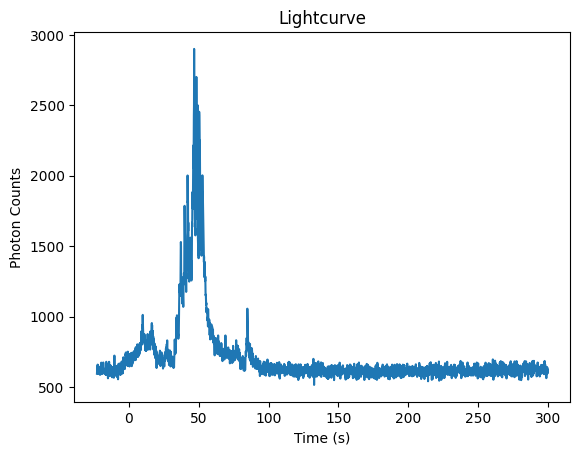

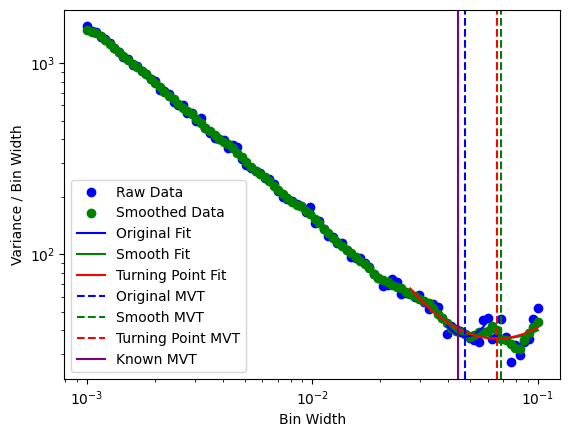

Would you like to run again?
1. Yes
2. No


In [5]:
rerun_flag = True

while rerun_flag == True:
  print("Would you like to use;\n1. Specific GRB\n2. Random GRB\n3. Sample Set\n4. All Avaliable GRBs")
  program_input = input("Enter 1-4:\t")

  if program_input == "1":   #Specific GRB input
    grb_name = input("Enter GRB Name (GRB#########):\t")
    single(grb_name)

  elif program_input == "2":   #Random GRB
    random_index = random.randint(0, len(df))
    grb_row = df.iloc[random_index]
    grb_name = "GRB" + str(grb_row["TriggerID"])
    single(grb_name)

  elif program_input == "3":   #Random sample
    sample_size = int(input("Enter Sample Size:\t"))

    sample_indices = random.sample(range(0, len(df)), sample_size)
    grb_sample = []
    for i in sample_indices:
      grb_row = df.iloc[i]
      grb_sample.append("GRB" + str(grb_row["TriggerID"]))

    sampleSet(grb_sample)

  elif program_input == "4":   #Entire set
    grb_all = df['TriggerID'].values.tolist()
    grb_all = [str(i) for i in grb_all]
    grb_all = ["GRB" + str(i) for i in grb_all]
    fullSet(grb_all)


  print("Would you like to run again?\n1. Yes\n2. No")   #Run program again
  rerun_input = input()
  if rerun_input == "2":
    rerun_flag = False
